기존 CMVTS : 0.9338
  C1(1-JSD) : 0.9559  ← 균등분포 가정
  C2(|rho|) : 0.8896
  C3(CosSim): 0.9485

[통신CB 매핑 변수 확인]
  comm_sns_22_1        → R3M_ITRT_COMM_SNS              n=330,000  mean=1.06  missing=0.0%
  shc_236_222Q         → CD_USE_AMT                     n=330,000  mean=5690.29  missing=0.0%
  shop_social_22_2     → R3M_ITRT_SHOP_SOCIAL           n=330,000  mean=0.78  missing=0.0%
  shop_jikgu_22_2      → R3M_ITRT_SHOP_JIKGU            n=330,000  mean=0.38  missing=0.0%

전체 통신CB 파일 로드 중...
통합 shape : (2640000, 6)
기준년월   : [202103, 202106, 202109, 202112, 202203, 202206, 202209, 202212]

[변수별 JSD 계산 — 실측 분포 기반]
  comm_sns_22_1         Korea dist: [0.708 0.27  0.021 0.    0.   ]
                        ID proxy  : [0.233 0.233 0.233 0.15  0.15 ]
                        JSD=0.5620  1-JSD=0.4380

  shc_236_222Q          Korea dist: [0.2 0.2 0.2 0.2 0.2]
                        ID proxy  : [0.285 0.285 0.143 0.143 0.143]
                        JSD=0.1448  1-JSD=0.8552

  shop_social_22_2 

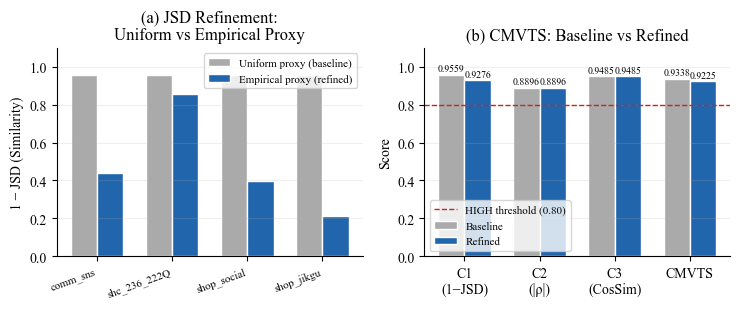


저장 완료:
  outputs/tables/04b_jsd_telecom.csv
  outputs/tables/04b_jsd_combined.csv
  outputs/tables/04b_telecom_descriptive.csv
  outputs/tables/04b_cmvts_comparison.csv
  outputs/figures/Fig5_jsd_refinement.pdf/png

→ [8]셀 CMVTS 개선 결과 확인


In [5]:
# ============================================================
# 04b_telecom_jsd_refinement
# 통신카드CB 결합 데이터를 활용한 JSD 컴포넌트 고도화
# 균등분포 가정 → 한국 실측 분포로 교체
# CMVTS 재산출 및 기존 결과와 비교
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import warnings
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman', 'DejaVu Serif'],
    'font.size'        : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# %% [2] 기존 CMVTS 기준값 로드
cmvts_df = pd.read_csv('outputs/tables/04_cmvts_results.csv')
C1_old   = cmvts_df[cmvts_df['component']=='1-JSD_mean']['value'].values[0]
C2       = cmvts_df[cmvts_df['component']=='|Spearman_rho|']['value'].values[0]
C3       = cmvts_df[cmvts_df['component']=='CosSim']['value'].values[0]
CMVTS_OLD = cmvts_df[cmvts_df['component']=='CMVTS']['value'].values[0]

print(f"기존 CMVTS : {CMVTS_OLD:.4f}")
print(f"  C1(1-JSD) : {C1_old:.4f}  ← 균등분포 가정")
print(f"  C2(|rho|) : {C2:.4f}")
print(f"  C3(CosSim): {C3:.4f}")

# %% [3] 연구기획서 11개 공통변수 — 통신CB 매핑 확정
# 변수명 : (통신CB 컬럼, 인도네시아 Statista 대응 수치, 수치 출처)
TELECOM_MAP = {
    'comm_sns_22_1'   : {
        'col'      : 'R3M_ITRT_COMM_SNS',
        'id_value' : 70.0,   # 인도네시아 소셜미디어 보급률 70% (Statista)
        'id_source': 'Social media penetration Indonesia 2021',
        'desc'     : 'SNS community interest score'
    },
    'shc_236_222Q'    : {
        'col'      : 'CD_USE_AMT',
        'id_value' : 57.0,   # 인도네시아 eCommerce 보급률 57%
        'id_source': 'eCommerce penetration Indonesia 2021',
        'desc'     : 'e-Commerce usage amount'
    },
    'shop_social_22_2': {
        'col'      : 'R3M_ITRT_SHOP_SOCIAL',
        'id_value' : 57.0,   # eCommerce 동일 기준
        'id_source': 'eCommerce penetration Indonesia 2021',
        'desc'     : 'Social commerce interest score'
    },
    'shop_jikgu_22_2' : {
        'col'      : 'R3M_ITRT_SHOP_JIKGU',
        'id_value' : 19.0,   # 인도네시아 해외직구 관심도 (Statista)
        'id_source': 'Cross-border shopping Indonesia 2021',
        'desc'     : 'Overseas direct purchase interest'
    },
}

print("\n[통신CB 매핑 변수 확인]")
files = sorted(glob.glob('data/aihub_raw/*통신카드CB결합*.csv'))
df_tel = pd.read_csv(files[-1], encoding='cp949', low_memory=False)

for nm, info in TELECOM_MAP.items():
    col = info['col']
    if col in df_tel.columns:
        s = df_tel[col].dropna()
        print(f"  {nm:<20} → {col:<30} "
              f"n={len(s):,}  mean={s.mean():.2f}  "
              f"missing={df_tel[col].isnull().mean()*100:.1f}%")
    else:
        print(f"  {nm:<20} → {col:<30} ← 컬럼 없음")

# %% [4] 전체 시점 파일 통합 (8개 분기)
print("\n전체 통신CB 파일 로드 중...")
dfs = []
for f in files:
    tmp = pd.read_csv(f, encoding='cp949',
                      usecols=['BASE_YM', 'CUST_ID'] +
                              [v['col'] for v in TELECOM_MAP.values()
                               if v['col'] in df_tel.columns],
                      low_memory=False)
    dfs.append(tmp)

df_all = pd.concat(dfs, ignore_index=True)
print(f"통합 shape : {df_all.shape}")
print(f"기준년월   : {sorted(df_all['BASE_YM'].unique())}")

# %% [5] 한국 실측 분포 추출 — 변수별 분위수 기반 bin 생성
def get_korea_dist(series, n_bins=5):
    """분위수 기반 동일구간 bin → 정확히 n_bins 크기 반환"""
    s = series.dropna()
    if len(s) == 0:
        return np.ones(n_bins) / n_bins
    # pd.qcut으로 정확히 n_bins 구간 생성 (중복 경계값 자동 처리)
    try:
        cut = pd.qcut(s, q=n_bins, duplicates='drop')
        counts = cut.value_counts().sort_index().values.astype(float)
    except Exception:
        counts = np.ones(n_bins)
    # 결과가 n_bins보다 작을 경우 0으로 패딩
    if len(counts) < n_bins:
        counts = np.pad(counts, (0, n_bins - len(counts)), constant_values=1e-6)
    elif len(counts) > n_bins:
        counts = counts[:n_bins]
    counts = np.where(counts <= 0, 1e-6, counts)
    return counts / counts.sum()

def get_id_dist(id_value, n_bins=5):
    """
    인도네시아 단일 수치(보급률 %) → 분포 추정
    보급률 p% 의미: 전체 중 p%가 '이용' → Bernoulli 기반 2구간 확장
    n_bins 구간으로 선형 보간
    """
    p = id_value / 100.0
    # 이용 구간에 p 비중, 비이용에 (1-p) 비중을 n_bins로 확장
    mid = int(n_bins * p)
    mid = max(1, min(n_bins - 1, mid))
    dist = np.ones(n_bins) * (1 - p) / (n_bins - mid)
    dist[:mid] = p / mid
    dist = np.where(dist <= 0, 1e-6, dist)
    return dist / dist.sum()

# %% [6] 변수별 JSD 계산 (실측 분포 vs 인도네시아 프록시)
print("\n[변수별 JSD 계산 — 실측 분포 기반]")
jsd_refined = []
N_BINS = 5

for nm, info in TELECOM_MAP.items():
    col = info['col']
    if col not in df_all.columns:
        continue

    korea_raw  = get_korea_dist(df_all[col], N_BINS)
    id_proxy   = get_id_dist(info['id_value'], N_BINS)
    jsd_val    = jensenshannon(korea_raw, id_proxy, base=2)
    sim        = 1 - jsd_val

    print(f"  {nm:<20}  Korea dist: {np.round(korea_raw,3)}")
    print(f"  {'':<20}  ID proxy  : {np.round(id_proxy,3)}")
    print(f"  {'':<20}  JSD={jsd_val:.4f}  1-JSD={sim:.4f}\n")

    jsd_refined.append({
        'variable'  : nm,
        'column'    : col,
        'jsd'       : round(jsd_val, 6),
        'sim_jsd'   : round(sim, 6),
        'id_value'  : info['id_value'],
        'id_source' : info['id_source'],
        'desc'      : info['desc'],
    })

jsd_ref_df = pd.DataFrame(jsd_refined)

# %% [7] 기존 개인CB JSD + 통신CB JSD 통합
jsd_cb_df = pd.read_csv('outputs/tables/04_jsd_by_variable.csv')

# 통신CB 변수 JSD를 추가
jsd_combined = pd.concat([
    jsd_cb_df[['variable','jsd','sim_jsd']],
    jsd_ref_df[['variable','jsd','sim_jsd']]
], ignore_index=True)

jsd_mean_new = jsd_combined['jsd'].mean()
C1_new       = 1 - jsd_mean_new

print(f"\n[JSD 통합 결과]")
print(f"  개인CB 변수 수        : {len(jsd_cb_df)}개")
print(f"  통신CB 추가 변수 수   : {len(jsd_ref_df)}개")
print(f"  통합 변수 수          : {len(jsd_combined)}개")
print(f"\n  JSD 평균 (기존)      : {1-C1_old:.4f}  → 1-JSD = {C1_old:.4f}")
print(f"  JSD 평균 (개선)      : {jsd_mean_new:.4f}  → 1-JSD = {C1_new:.4f}")
print(f"  변화량               : {C1_new - C1_old:+.4f}")

# %% [8] CMVTS 재산출
w1, w2, w3 = 0.4, 0.3, 0.3
CMVTS_NEW = w1 * C1_new + w2 * C2 + w3 * C3

print(f"\n{'='*55}")
print(f"  CMVTS 비교 (기존 vs 개선)")
print(f"{'='*55}")
print(f"  {'':30} {'기존':>8} {'개선':>8} {'변화':>8}")
print(f"  {'-'*52}")
print(f"  {'C1: 1-JSD_mean':<30} {C1_old:>8.4f} {C1_new:>8.4f} "
      f"{C1_new-C1_old:>+8.4f}")
print(f"  {'C2: |Spearman rho|':<30} {C2:>8.4f} {C2:>8.4f} {'—':>8}")
print(f"  {'C3: CosSim':<30} {C3:>8.4f} {C3:>8.4f} {'—':>8}")
print(f"  {'-'*52}")
print(f"  {'CMVTS':<30} {CMVTS_OLD:>8.4f} {CMVTS_NEW:>8.4f} "
      f"{CMVTS_NEW-CMVTS_OLD:>+8.4f}")
print(f"{'='*55}")

if CMVTS_NEW >= 0.80:
    print(f"\n  판정 : HIGH — Direct transfer recommended")
elif CMVTS_NEW >= 0.60:
    print(f"\n  판정 : MEDIUM — Partial adjustment recommended")
else:
    print(f"\n  판정 : LOW — Local redevelopment recommended")

# %% [9] 기술통계 — 논문 Section 4.2용
print("\n[통신CB 대안변수 기술통계 — 논문 Table용]")
desc_rows = []
for nm, info in TELECOM_MAP.items():
    col = info['col']
    if col not in df_all.columns:
        continue
    s = df_all[col].dropna()
    desc_rows.append({
        'Variable (report)'   : nm,
        'Column (AI Hub)'     : col,
        'Description'         : info['desc'],
        'N'                   : f"{len(s):,}",
        'Mean'                : round(s.mean(), 3),
        'Std'                 : round(s.std(),  3),
        'Min'                 : round(s.min(),  3),
        'Median'              : round(s.median(), 3),
        'Max'                 : round(s.max(),  3),
        'Missing%'            : round(df_all[col].isnull().mean()*100, 1),
        'ID proxy (%)'        : info['id_value'],
        'ID source'           : info['id_source'],
    })

desc_df = pd.DataFrame(desc_rows)
print(desc_df[['Variable (report)','Column (AI Hub)',
               'Mean','Std','Missing%','ID proxy (%)']].to_string(index=False))

# %% [10] 시각화
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.2))

# 왼쪽: JSD 개선 전후 비교
vars_show = jsd_ref_df['variable'].tolist()
x = np.arange(len(vars_show))
w = 0.35
old_jsd = [jsd_cb_df[jsd_cb_df['variable']==v]['sim_jsd'].values[0]
           if v in jsd_cb_df['variable'].values else C1_old
           for v in vars_show]
new_jsd = jsd_ref_df['sim_jsd'].tolist()

axes[0].bar(x - w/2, old_jsd, width=w, label='Uniform proxy (baseline)',
            color='#AAAAAA', edgecolor='white')
axes[0].bar(x + w/2, new_jsd, width=w, label='Empirical proxy (refined)',
            color='#2166ac', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([v.replace('_22_1','').replace('_22_2','')
                          for v in vars_show], rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('1 − JSD (Similarity)')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('(a) JSD Refinement:\nUniform vs Empirical Proxy')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.2)

# 오른쪽: CMVTS 비교 바차트
labels   = ['C1\n(1−JSD)', 'C2\n(|ρ|)', 'C3\n(CosSim)', 'CMVTS']
old_vals = [C1_old, C2, C3, CMVTS_OLD]
new_vals = [C1_new, C2, C3, CMVTS_NEW]
x2 = np.arange(len(labels))
axes[1].bar(x2 - w/2, old_vals, width=w, label='Baseline',
            color='#AAAAAA', edgecolor='white')
axes[1].bar(x2 + w/2, new_vals, width=w, label='Refined',
            color='#2166ac', edgecolor='white')
axes[1].axhline(y=0.80, color='#CC2222', linestyle='--',
                lw=1, label='HIGH threshold (0.80)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('(b) CMVTS: Baseline vs Refined')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.2)
for i, (ov, nv) in enumerate(zip(old_vals, new_vals)):
    axes[1].text(i-w/2, ov+0.02, f'{ov:.4f}', ha='center', fontsize=7)
    axes[1].text(i+w/2, nv+0.02, f'{nv:.4f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('outputs/figures/Fig5_jsd_refinement.pdf', bbox_inches='tight')
plt.savefig('outputs/figures/Fig5_jsd_refinement.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [11] 저장
jsd_ref_df.to_csv('outputs/tables/04b_jsd_telecom.csv',
                  index=False, encoding='utf-8-sig')
jsd_combined.to_csv('outputs/tables/04b_jsd_combined.csv',
                    index=False, encoding='utf-8-sig')
desc_df.to_csv('outputs/tables/04b_telecom_descriptive.csv',
               index=False, encoding='utf-8-sig')

pd.DataFrame([{
    'version'        : 'baseline',
    'C1_1-JSD'       : C1_old,
    'C2_spearman'    : C2,
    'C3_cossim'      : C3,
    'CMVTS'          : CMVTS_OLD,
    'JSD_vars'       : len(jsd_cb_df),
    'note'           : 'Uniform proxy for ID distribution'
},{
    'version'        : 'refined',
    'C1_1-JSD'       : C1_new,
    'C2_spearman'    : C2,
    'C3_cossim'      : C3,
    'CMVTS'          : CMVTS_NEW,
    'JSD_vars'       : len(jsd_combined),
    'note'           : 'Empirical proxy from telecom-CB data'
}]).to_csv('outputs/tables/04b_cmvts_comparison.csv',
           index=False, encoding='utf-8-sig')

print("\n저장 완료:")
print("  outputs/tables/04b_jsd_telecom.csv")
print("  outputs/tables/04b_jsd_combined.csv")
print("  outputs/tables/04b_telecom_descriptive.csv")
print("  outputs/tables/04b_cmvts_comparison.csv")
print("  outputs/figures/Fig5_jsd_refinement.pdf/png")
print("\n→ [8]셀 CMVTS 개선 결과 확인")